# COMP545 RAG Project – Outline

This notebook implements a **Retrieval-Augmented Generation (RAG)** pipeline and evaluation framework.

High-level stages:

1. Config & environment.
2. Data loading (queries + corpus).
3. Corpus → chunks → embeddings → Chroma (baseline index).
4. LLM setup
5. Logic graph construction.
6. Retrieval modules:
   - baseline_retrieve
   - graph_retrieve
7. RAG answerers:
   - answer_query_baseline
   - answer_query_graph
8. Evaluators (retrieval & generation).

## 1. Environment Setup & Dependencies


In [2]:
import os
import json
from dataclasses import dataclass
from typing import List, Dict, Any, Tuple, Optional
import pandas as pd
import numpy as np
import torch
import transformers
from PyPDF2 import PdfReader
import pdfplumber
import networkx as nx
import re

# LangChain
from langchain.llms import HuggingFacePipeline
from langchain.schema import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma
from langchain.chains import RetrievalQA

# ==== Paths ====
QUERIES_PATH = "data/test.json"
PDF_PATH     = "data/book.pdf"
CHROMA_DIR   = "chroma_db"

# device
if torch.cuda.is_available():
    DEVICE = "cuda" # windows or linux
elif torch.backends.mps.is_available():
    DEVICE = "mps" # macOS
else:
    DEVICE = "cpu" 
print("Using device:", DEVICE)


Using device: cuda


## 2. (PDF → Sections)
- Corpus: `book.pdf`
- Queries: `queries.json` with:
  - `query_id`
  - `question`


In [3]:
df_queries = pd.read_json(QUERIES_PATH)
print(df_queries.head())
print(f"Loaded {len(df_queries)} queries.")

   id  chapter                                           question  \
0  q1        1  Who is seen as the father of behaviorism withi...   
1  q2        1  What area of psychology receives the most atte...   
2  q3        2  What is the difference between Deductive and I...   
3  q4        2        What is an example of positive correlation?   
4  q5        3                 What are Psychotropic Medications?   

                                              answer relevant_pages  \
0                                     John B. Watson           [13]   
1                                Clinical Psychology           [26]   
2  For Deductive Reasoning, ideas are tested in t...           [39]   
3  1. Ice cream and crime rates; 2. An individual...           [49]   
4  Drugs that treat psychiatric symptoms by resto...           [83]   

                 relevant_sections  
0        1.2 History of Psychology  
1      1.3 Contemporary Psychology  
2   2.1 Why is Research Important?  
3         

In [4]:
def load_book_with_page_overlap(pdf_path: str, overlap_size: int = 0):
    """
    Open the PDF, and for each page, 
    1. extract text
    2. Combine a few words from the end of the previous page with the current page(overlap)
    3. Returns a list of dicts: [{"page": int, "text": str}, ...].
    """
    sections = []

    def overlap_pages(page_text: str, next_page_text: str, overlap_size: int) -> str:
        page_words = page_text.split()
        next_page_words = next_page_text.split()
        overlap = page_words[-overlap_size:] if len(page_words) > overlap_size else page_words
        return " ".join(overlap) + " " + " ".join(next_page_words)

    def normalize_text(text: str) -> str:
        # collapse weird whitespace from extractor (e.g., “Attributi on”)
        text = re.sub(r"\s+", " ", text)
        return text.strip()

    try:
        with pdfplumber.open(pdf_path) as pdf:
            previous_page_text = None
            for page_num, page in enumerate(pdf.pages):
                text = page.extract_text()
                if text and text.strip():
                    text = normalize_text(text)
                    if previous_page_text:
                        combined_text = overlap_pages(previous_page_text, text, overlap_size)
                        sections.append({"page": page_num + 1, "text": combined_text})
                    else:
                        sections.append({"page": page_num + 1, "text": text})
                    previous_page_text = text
        return sections
    except Exception as e:
        print(f"Error loading PDF with pdfplumber: {e}")
        print("Falling back to PyPDF2...")
    
    # fallback to PyPDF2 if pdfplumber fails
    try:
        reader = PdfReader(pdf_path, strict=False)
        previous_page_text = None
        for page_num, page in enumerate(reader.pages):
            text = page.extract_text()
            if text and text.strip():
                text = normalize_text(text)
                if previous_page_text:
                    combined_text = overlap_pages(previous_page_text, text, overlap_size)
                    sections.append({"page": page_num + 1, "text": combined_text})
                else:
                    sections.append({"page": page_num + 1, "text": text})
                previous_page_text = text
    except Exception as e:
        print(f"Error loading PDF with PyPDF2: {e}")

    return sections

In [5]:
# Load the corpus PDF
PDF_PATH = "data/book.pdf"

book_data = load_book_with_page_overlap(PDF_PATH, overlap_size=5)
print(f"Loaded {len(book_data)} sections (pages).")

# Quick sanity check
for i, section in enumerate(book_data[:3]):
    print(f"Page {section['page']} snippet: {section['text'][:200]}...\n")


Loaded 751 sections (pages).
Page 3 snippet: Psychology 2e SENIOR CONTRIBUTING AUTHORS ROSE M. SPIELMAN, FORMERLY OF QUINNIPIAC UNIVERSITY WILLIAM J. JENKINS, MERCER UNIVERSITY MARILYN D. LOVETT, SPELMAN COLLEGE...

Page 4 snippet: MARILYN D. LOVETT, SPELMAN COLLEGE OpenStax Rice University 6100 Main Street MS-375 Houston, Texas 77005 To learn more about OpenStax, visit https://openstax.org. Individual print copies and bulk orde...

Page 5 snippet: 9 10 JAY 22 20 OPENSTAX OpenStax provides free, peer-reviewed, openly licensed textbooks for introductory college and Advanced Placement® courses and low-cost, personalized courseware that helps stude...



## 3. Documents → Chunks → Embeddings → Chroma
0**. add section and chapter information to metadata
1. Wrap each page section as a LangChain `Document`.
2. Chunk documents into smaller passages.
3. Embed each chunk.
4. Store everything in a Chroma vector store (baseline index).

In [6]:
#3.0** Enrich metadata with section/chapter info from TOC
#check toc is available
from PyPDF2 import PdfReader
reader = PdfReader("data/book.pdf")
toc = reader.outline   # sometimes contains chapters/sections
print(toc)

from PyPDF2 import PdfReader, generic

PDF_PATH = "data/book.pdf"
reader = PdfReader(PDF_PATH)
outline = reader.outline

def flatten_outline(outline_items, reader):
    """
    Flatten PyPDF2 outline into:
    [
      {"title": ..., "page": <1-based>, "parent": <str or None>},
      ...
    ]
    where 'parent' reflects the outline tree (chapter for its sections).
    """
    flat = []

    def walk(items, parent_title=None):#recursive function to walk through outline items and flatten them
        last_title = None  # last non-list title at this level

        for item in items:
            if isinstance(item, list):
                # a child list: all its entries share the same parent = last_title
                if last_title is not None:
                    walk(item, parent_title=last_title)
                else:
                    # defensive: list without a preceding title
                    walk(item, parent_title=parent_title)
            else:
                title = item["/Title"]

                page_obj = item["/Page"]
                if isinstance(page_obj, generic.IndirectObject):
                    page_index = reader.pages.index(page_obj)
                else:
                    try:
                        page_index = reader.get_destination_page_number(item)
                    except Exception:
                        page_index = 0

                flat.append({
                    "title": title,
                    "page": page_index + 1,
                    "parent": parent_title,
                })

                # this is now the parent of any immediately following child list
                last_title = title

    walk(outline_items, parent_title=None)
    return flat

flat_outline = flatten_outline(outline, reader)

print("First 10 outline entries:")
for e in flat_outline[:10]:
    print(e)


[{'/Title': 'Contents', '/Page': IndirectObject(18, 0, 2158771795472), '/Type': '/XYZ', '/Left': 0, '/Top': 734, '/Zoom': 0}, {'/Title': 'Preface', '/Page': IndirectObject(35, 0, 2158771795472), '/Type': '/XYZ', '/Left': 0, '/Top': 734, '/Zoom': 0}, {'/Title': 'Chapter 1 Introduction to Psychology', '/Page': IndirectObject(48, 0, 2158771795472), '/Type': '/XYZ', '/Left': 0, '/Top': 745, '/Zoom': 0, '/Count': 10}, [{'/Title': 'Introduction', '/Page': IndirectObject(48, 0, 2158771795472), '/Type': '/XYZ', '/Left': 0, '/Top': 172, '/Zoom': 0}, {'/Title': '1.1 What Is Psychology?', '/Page': IndirectObject(52, 0, 2158771795472), '/Type': '/XYZ', '/Left': 0, '/Top': 674, '/Zoom': 0}, {'/Title': '1.2 History of Psychology', '/Page': IndirectObject(54, 0, 2158771795472), '/Type': '/XYZ', '/Left': 0, '/Top': 452, '/Zoom': 0}, {'/Title': '1.3 Contemporary Psychology', '/Page': IndirectObject(84, 0, 2158771795472), '/Type': '/XYZ', '/Left': 0, '/Top': 353, '/Zoom': 0}, {'/Title': '1.4 Careers in 

In [7]:
# add helper functions(page -> section/chapter)
# flat_outline already exists: list of {"title", "page", "parent"}

# --- classify titles ---

def is_chapter_title(title: str) -> bool:
    # e.g., "Chapter 1 Introduction to Psychology"
    return title.strip().startswith("Chapter ")

def is_section_title(title: str) -> bool:
    # e.g., "1.1 What Is Psychology?"
    return re.match(r"^\d+(\.\d+)*", title.strip()) is not None

chapter_entries = [e for e in flat_outline if is_chapter_title(e["title"])] #filter chapter titles
section_entries = [e for e in flat_outline if is_section_title(e["title"])] #filter section titles

chapter_entries = sorted(chapter_entries, key=lambda x: x["page"])
section_entries = sorted(section_entries, key=lambda x: x["page"])

print("Example chapter entries:")
for e in chapter_entries[:5]:
    print(e)

print("\nExample section entries:")
for e in section_entries[:5]:
    print(e)


Example chapter entries:
{'title': 'Chapter 1 Introduction to Psychology', 'page': 19, 'parent': None}
{'title': 'Chapter 2 Psychological Research', 'page': 47, 'parent': None}
{'title': 'Chapter 3 Biopsychology', 'page': 83, 'parent': None}
{'title': 'Chapter 4 States of Consciousness', 'page': 121, 'parent': None}
{'title': 'Chapter 5 Sensation and Perception', 'page': 157, 'parent': None}

Example section entries:
{'title': '1.1 What Is Psychology?', 'page': 20, 'parent': 'Chapter 1 Introduction to Psychology'}
{'title': '1.2 History of Psychology', 'page': 21, 'parent': 'Chapter 1 Introduction to Psychology'}
{'title': '1.3 Contemporary Psychology', 'page': 30, 'parent': 'Chapter 1 Introduction to Psychology'}
{'title': '1.4 Careers in Psychology', 'page': 38, 'parent': 'Chapter 1 Introduction to Psychology'}
{'title': '2.1 Why Is Research Important?', 'page': 48, 'parent': 'Chapter 2 Psychological Research'}


In [8]:
# build page -> chapter/section mapping
num_pages = len(reader.pages)

def build_page_mapping(entries, num_pages):
    """
    Given entries sorted by 'page', build
    page_number (1-based) -> last entry.title whose page <= page_number.
    """
    if not entries:
        return {p: None for p in range(1, num_pages + 1)}

    page_to_label = {}
    idx = 0

    for page in range(1, num_pages + 1):
        while idx + 1 < len(entries) and entries[idx + 1]["page"] <= page: #if next entry's page is less than or equal to current page, move to next entry
            idx += 1
        page_to_label[page] = entries[idx]["title"]#until next entry's page is greater than current page, assign current entry's title to this page

    return page_to_label

page_to_chapter = build_page_mapping(chapter_entries, num_pages)
page_to_section = build_page_mapping(section_entries, num_pages)

# quick sanity check
for p in range(18, 26):
    print(f"Page {p}: chapter='{page_to_chapter.get(p)}', section='{page_to_section.get(p)}'")


Page 18: chapter='Chapter 1 Introduction to Psychology', section='1.1 What Is Psychology?'
Page 19: chapter='Chapter 1 Introduction to Psychology', section='1.1 What Is Psychology?'
Page 20: chapter='Chapter 1 Introduction to Psychology', section='1.1 What Is Psychology?'
Page 21: chapter='Chapter 1 Introduction to Psychology', section='1.2 History of Psychology'
Page 22: chapter='Chapter 1 Introduction to Psychology', section='1.2 History of Psychology'
Page 23: chapter='Chapter 1 Introduction to Psychology', section='1.2 History of Psychology'
Page 24: chapter='Chapter 1 Introduction to Psychology', section='1.2 History of Psychology'
Page 25: chapter='Chapter 1 Introduction to Psychology', section='1.2 History of Psychology'


In [9]:
# 3.1 Convert sections to Documents
documents = []
for section in book_data:
    page_num = section["page"]

    documents.append(
        Document(
            page_content=section["text"],
            metadata={
                "page": page_num,
                "chapter": page_to_chapter.get(page_num),
                "section": page_to_section.get(page_num),
            },
        )
    )

print("Base documents:", len(documents))
print("Example document metadata:")
for d in documents[:5]:
    print(d.metadata)


print("Base documents:", len(documents))

# 3.2 Chunk documents
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100
)

all_splits = text_splitter.split_documents(documents)
print("Chunks after splitting:", len(all_splits))

# 3.3 Embedding model
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

embedding_model_kwargs = {"device": DEVICE}

embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    model_kwargs=embedding_model_kwargs,
)
#using BGE model for embedding
# EMBEDDING_MODEL_NAME = "BAAI/bge-small-en-v1.5"

# embedding_model_kwargs = {
#     "device": DEVICE,
# }

# encode_kwargs = {
#     "normalize_embeddings": True  # very important for cosine similarity
# }

# embeddings = HuggingFaceEmbeddings(
#     model_name=EMBEDDING_MODEL_NAME,
#     model_kwargs=embedding_model_kwargs,
#     encode_kwargs=encode_kwargs,
# )

# 3.4 Chroma vector store
CHROMA_DIR = "chroma_db"

vectordb = Chroma.from_documents(
    documents=all_splits,
    embedding=embeddings,
    persist_directory=CHROMA_DIR
)

print("Chroma vector store built and persisted to:", CHROMA_DIR)
# Print metadata of first 5 chunks
for i, chunk in enumerate(all_splits[:5]):
    print(f"Chunk {i} metadata:", chunk.metadata)


Base documents: 751
Example document metadata:
{'page': 3, 'chapter': 'Chapter 1 Introduction to Psychology', 'section': '1.1 What Is Psychology?'}
{'page': 4, 'chapter': 'Chapter 1 Introduction to Psychology', 'section': '1.1 What Is Psychology?'}
{'page': 5, 'chapter': 'Chapter 1 Introduction to Psychology', 'section': '1.1 What Is Psychology?'}
{'page': 6, 'chapter': 'Chapter 1 Introduction to Psychology', 'section': '1.1 What Is Psychology?'}
{'page': 7, 'chapter': 'Chapter 1 Introduction to Psychology', 'section': '1.1 What Is Psychology?'}
Base documents: 751
Chunks after splitting: 2796


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1358.52it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Chroma vector store built and persisted to: chroma_db
Chunk 0 metadata: {'page': 3, 'chapter': 'Chapter 1 Introduction to Psychology', 'section': '1.1 What Is Psychology?'}
Chunk 1 metadata: {'page': 4, 'chapter': 'Chapter 1 Introduction to Psychology', 'section': '1.1 What Is Psychology?'}
Chunk 2 metadata: {'page': 4, 'chapter': 'Chapter 1 Introduction to Psychology', 'section': '1.1 What Is Psychology?'}
Chunk 3 metadata: {'page': 5, 'chapter': 'Chapter 1 Introduction to Psychology', 'section': '1.1 What Is Psychology?'}
Chunk 4 metadata: {'page': 5, 'chapter': 'Chapter 1 Introduction to Psychology', 'section': '1.1 What Is Psychology?'}


In [14]:
# test only
def check_split_quality(chunks):
    problematic_chunks = []
    
    for i, chunk in enumerate(chunks):
        text = chunk.page_content
        
        words = text.split()
        if words:
            first_word = words[0]
            if len(first_word) == 1 or (len(first_word) < 4 and first_word.isalpha()):
                problematic_chunks.append((i, "starts_with_short_word", first_word))
            
            last_word = words[-1]
            if len(last_word) == 1 or (len(last_word) < 4 and last_word.isalpha()):
                problematic_chunks.append((i, "ends_with_short_word", last_word))
    
    return problematic_chunks

problems = check_split_quality(all_splits[:20])
print(f"Found {len(problems)} potential split issues in first 20 chunks")
for prob in problems:
    print(f"Chunk {prob[0]}: {prob[1]} - '{prob[2]}'")

Found 10 potential split issues in first 20 chunks
Chunk 2: starts_with_short_word - 'of'
Chunk 3: starts_with_short_word - '9'
Chunk 3: ends_with_short_word - 'and'
Chunk 4: starts_with_short_word - 'for'
Chunk 7: starts_with_short_word - 'The'
Chunk 10: ends_with_short_word - 'and'
Chunk 15: starts_with_short_word - 'Key'
Chunk 17: ends_with_short_word - 'a'
Chunk 18: starts_with_short_word - 'and'
Chunk 19: ends_with_short_word - 'on'


## 4. LLM Setup (Gemma or other)
We load a causal LLM (e.g., Gemma-2-2B-IT) with `transformers`, create a
`text-generation` pipeline, and wrap it as a LangChain `llm`.

In [ ]:
# from transformers import AutoModelForCausalLM, AutoTokenizer
# import transformers
# from langchain.llms import HuggingFacePipeline
# import torch

# # Official Phi-3 mini instruct model on Hugging Face
# MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"

# model = AutoModelForCausalLM.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.float16 if DEVICE != "cpu" else torch.float32,
#     device_map={"": DEVICE},  # or "auto"
# )

# tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
# if tokenizer.pad_token is None:
#     tokenizer.pad_token = tokenizer.eos_token

# generation_pipeline = transformers.pipeline(
#     "text-generation",
#     model=model,
#     tokenizer=tokenizer,
#     torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
#     device_map="auto",
#     max_length=1024,
#     model_kwargs={
#         "max_new_tokens": 80,
#         "temperature": 0.0,
#         "do_sample": False,
#         "pad_token_id": tokenizer.pad_token_id,
#     },
# )

# llm = HuggingFacePipeline(pipeline=generation_pipeline)
# print("LLM ready (Phi-3 mini 4k instruct from HF Hub).")


# run in terminal
pip install huggingface_hub
huggingface-cli download --resume-download microsoft/Phi-3-mini-4k-instruct --local-dir ./phi-3-model

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

#MODEL_ID = "google/gemma-2-2b-it"  #we could change any LLm we want!
# MODEL_ID = "D./phi-3-model"
MODEL_ID = "D:/phi-3-model"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if DEVICE != "cpu" else torch.float32,
    device_map={"": DEVICE},
    
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

#create llm pipeline(tokenize prompt -> Send tensors to GPU-> Call model.generate(...)-> decode tokens back to text)
generation_pipeline = transformers.pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    device_map="auto",
    max_length=1024,
    model_kwargs={
        "max_new_tokens": 80,
        "temperature": 0.0,
        "do_sample": False,
    },
)

llm = HuggingFacePipeline(pipeline=generation_pipeline)
print("LLM ready.")


## 5. Logic Graph Construction

We build a **logic graph** on top of the chunks.
Design (first version):

- **Nodes**: chunk IDs (and optionally extra "concept" nodes later).
- **Node attributes**:
  - `page`: page number
  - `text`: chunk text
  - embedding vector (optional or stored externally)
- **Edges** (first simple design):
  - *Adjacency edges*: between consecutive chunks in the same page.
  - *Section / topic edges* (later): based on headings, keywords, or high cosine similarity.

Goal: 
- Expand from an initially retrieved chunk to its neighbors.
- Re-rank chunks based on graph connectivity.


In [10]:
def build_logic_graph(chunks: List[Document], embeddings: Optional[np.ndarray] = None) -> nx.Graph:
    G = nx.MultiGraph()

    # add nodes
    for idx, chunk in enumerate(chunks): #for each word in 1000 words chunk
        node_id = f"chunk_{idx}" 
        attributes = {
            'chunk_id': idx,
            'text': chunk.page_content,
            'page': chunk.metadata.get('page', 'unknown'),
            'chapter': chunk.metadata.get('chapter'),
            'section': chunk.metadata.get('section'),
            'source': chunk.metadata.get('source', 'unknown'),
            'metadata': chunk.metadata
        }
        if hasattr(chunk, 'embedding') and chunk.embedding is not None:
            attributes['embedding'] = chunk.embedding
        G.add_node(node_id, **attributes)
    
     # ===================================1. add adjacency edges (chunks within the same page)===============================
    page_chunks = {}
    for idx, chunk in enumerate(chunks):
        page = chunk.metadata.get('page', 'unknown')
        if page not in page_chunks:
            page_chunks[page] = []
        page_chunks[page].append(idx) #page_chunk is a dict of page number to list of chunk indices
    
    for page, chunk_indices in page_chunks.items():
        chunk_indices.sort() 
        for i in range(len(chunk_indices)):
            for j in range(i + 1, len(chunk_indices)):
                node1 = f"chunk_{chunk_indices[i]}"
                node2 = f"chunk_{chunk_indices[j]}"
                distance = j - i
                weight = 0.1 / distance
                G.add_edge(node1, node2, type="adjacency", weight=weight)
                

    #  ========================================2. chapter_chain (coarse grouping)==================================
    chapter_chunks = {}
    for idx, chunk in enumerate(chunks):
        chap = chunk.metadata.get("chapter")
        if chap:
            chapter_chunks.setdefault(chap, []).append(idx)  # group chunk indices by chapter

    for chap, indices in chapter_chunks.items():
        indices.sort()  # sort chunk indices within the chapter
        for i in range(len(indices) - 1):
            node1 = f"chunk_{indices[i]}"
            node2 = f"chunk_{indices[i + 1]}"
            # smaller weight since chapter is coarser than section
            G.add_edge(node1, node2, type="chapter_chain", weight=1.0)
            
            
            
            
    # =================================3. add sequential edges (based on chunk order)=============================
    for idx in range(len(chunks) - 1):
        node1 = f"chunk_{idx}"
        node2 = f"chunk_{idx + 1}"
        G.add_edge(node1, node2, type="sequential", weight=2.0)

    # ===================================4. add semantic edges (based on embedding similarity)===============================
    if embeddings is not None:
        from sklearn.metrics.pairwise import cosine_similarity
        sim_matrix = cosine_similarity(embeddings)
        n = len(chunks)
        for i in range(n):
            for j in range(i + 1, n):
                if sim_matrix[i, j] > 0.7:
                    G.add_edge(f"chunk_{i}", f"chunk_{j}", type="semantic", weight=3.0*float(sim_matrix[i, j]))
    


    # =======================================5. section_chain edges====================================
    section_chunks = {}
    for idx, chunk in enumerate(chunks):
        sec = chunk.metadata.get("section")
        if sec:
            section_chunks.setdefault(sec, []).append(idx) #group chunk indices by section

    for sec, indices in section_chunks.items():
        indices.sort() #sort chunk indices within the section
        for i in range(len(indices) - 1):
            node1 = f"chunk_{indices[i]}"
            node2 = f"chunk_{indices[i + 1]}"
            G.add_edge(node1, node2, type="section_chain", weight=4.0)
            


    return G


chunk_texts = [chunk.page_content for chunk in all_splits]
chunk_embeddings = embeddings.embed_documents(chunk_texts)

logic_graph = build_logic_graph(all_splits, np.array(chunk_embeddings))
print(f"Logic graph built: {logic_graph.number_of_nodes()} nodes, {logic_graph.number_of_edges()} edges")
# Count edge types
edge_types = {}
for u, v, data in logic_graph.edges(data=True):
    t = data.get("type", "unknown")
    edge_types[t] = edge_types.get(t, 0) + 1

print(edge_types)


Logic graph built: 2796 nodes, 14098 edges
{'chapter_chain': 2780, 'sequential': 2795, 'section_chain': 2708, 'adjacency': 4271, 'semantic': 1544}


In [11]:
def analyze_graph_structure(G: nx.Graph):
    print("Logic Graph Analysis Report")
    print(f"Total nodes: {G.number_of_nodes()}")
    print(f"Total edges: {G.number_of_edges()}")
    
    # edge type analysis
    edge_types = {}
    for u, v, data in G.edges(data=True):
        edge_type = data.get('type', 'unknown')
        edge_types[edge_type] = edge_types.get(edge_type, 0) + 1
    
    print("\nEdge type distribution:")
    for edge_type, count in edge_types.items():
        print(f"  {edge_type}: {count} edges")
    
    # connectivity analysis
    connected_components = list(nx.connected_components(G))
    print(f"\nConnected components: {len(connected_components)}")
    
    component_sizes = [len(comp) for comp in connected_components]
    print(f"Largest component: {max(component_sizes)} nodes")
    print(f"Average component size: {np.mean(component_sizes):.1f} nodes")
    
    # page distribution
    pages = [data.get('page', 'unknown') for _, data in G.nodes(data=True)]
    unique_pages = set(pages)
    print(f"\nPages covered: {len(unique_pages)} distinct pages")
    
    # additional metrics
    if G.number_of_edges() > 0:
        density = nx.density(G)
        print(f"Graph density: {density:.4f}")
        
        # nx.average_clustering is not implemented for MultiGraph/MultiDiGraph, so flatten first
        if isinstance(G, (nx.MultiGraph, nx.MultiDiGraph)):
            simple_G = nx.Graph()
            simple_G.add_nodes_from(G.nodes(data=True))
            simple_G.add_edges_from((u, v) for u, v, _ in G.edges(keys=True))
        else:
            simple_G = G
        avg_clustering = nx.average_clustering(simple_G)
        print(f"Average clustering coefficient: {avg_clustering:.4f}")

analyze_graph_structure(logic_graph)

Logic Graph Analysis Report
Total nodes: 2796
Total edges: 14098

Edge type distribution:
  chapter_chain: 2780 edges
  sequential: 2795 edges
  section_chain: 2708 edges
  adjacency: 4271 edges
  semantic: 1544 edges

Connected components: 1
Largest component: 2796 nodes
Average component size: 2796.0 nodes

Pages covered: 751 distinct pages
Graph density: 0.0036
Average clustering coefficient: 0.6081


In [12]:
def expand_from_chunk(G: nx.Graph, chunk_id: str, max_depth: int = 2):
    if chunk_id not in G.nodes:
        return []
    
    visited = set()
    queue = [(chunk_id, 0)]
    relevant_chunks = []
    
    while queue:
        current_node, depth = queue.pop(0)
        if current_node not in visited and depth <= max_depth:
            visited.add(current_node)
            relevant_chunks.append(current_node)
            for neighbor in G.neighbors(current_node):
                if neighbor not in visited:
                    queue.append((neighbor, depth + 1))
    
    return relevant_chunks

# test expanded chunks
test_chunks = ["chunk_1", "chunk_50", "chunk_100"]
for test_chunk in test_chunks:
    if test_chunk in logic_graph.nodes:
        neighbors_count = len(list(logic_graph.neighbors(test_chunk)))
        print(f"{test_chunk}: {neighbors_count} neighbors")
        expanded_chunks = expand_from_chunk(logic_graph, test_chunk, max_depth=2)
        print(f"Expanded from {test_chunk} to {len(expanded_chunks)} related chunks")
        print(f"First 5 expanded chunks: {expanded_chunks[:5]}\n")

chunk_1: 3 neighbors
Expanded from chunk_1 to 8 related chunks
First 5 expanded chunks: ['chunk_1', 'chunk_2', 'chunk_0', 'chunk_19', 'chunk_3']

chunk_50: 3 neighbors
Expanded from chunk_50 to 9 related chunks
First 5 expanded chunks: ['chunk_50', 'chunk_51', 'chunk_52', 'chunk_49', 'chunk_53']

chunk_100: 3 neighbors
Expanded from chunk_100 to 8 related chunks
First 5 expanded chunks: ['chunk_100', 'chunk_101', 'chunk_102', 'chunk_99', 'chunk_103']



In [13]:
# 6.2 Graph-based retriever helper functions\
# How important each edge type is under different tasks
TASK_EDGE_WEIGHTS = {
    "default": {
        "adjacency": 0.1,
        "chapter_chain": 1.0,
        "sequential": 2.0,
        "semantic": 3.0,
        "section_chain": 4.0,
    },
    # For summarizing a whole chapter: emphasize chapter edges
    "summary": {
        "adjacency": 0.1,
        "chapter_chain": 7.0,   # much higher
        "sequential": 2.0,
        "semantic": 1.0,
        "section_chain": 2.0,
    },
    # For focused QA: emphasize semantic + section
    "fine_qa": {
        "adjacency": 0.1,
        "chapter_chain": 0.1,
        "sequential": 2.0,
        "semantic": 5.0,
        "section_chain": 2.0,
    },
}

def compute_node_score(G: nx.MultiGraph, node: str, task: str = "default") -> float:
    """
    Score a node by summing over all incident edges:
        score(node) = sum_{edges e=(node,nbr)} alpha[type_e] * weight_e
    where alpha[type] depends on the task.
    """
    alphas = TASK_EDGE_WEIGHTS.get(task, TASK_EDGE_WEIGHTS["default"])
    score = 0.0

    # G[node] -> dict: neighbor -> {edge_key: edge_data}
    for nbr, multiedges in G[node].items():
        for _, data in multiedges.items():
            etype = data.get("type")
            w = float(data.get("weight", 1.0))
            if etype in alphas:
                score += alphas[etype] * w #sum weighted contributions

    return score


In [14]:
def reorder_chunks_by_connectivity(
    G: nx.MultiGraph,
    chunk_ids: List[str],
    task: str = "default",
) -> List[str]:
    """
    Re-rank the candidate chunk_ids using graph connectivity under a given task.
    """
    if not chunk_ids:
        return []

    scored = []
    for cid in chunk_ids:
        if cid in G.nodes:
            s = compute_node_score(G, cid, task=task)
            scored.append((cid, s))
        else:
            scored.append((cid, 0.0))

    # sort by score descending
    scored.sort(key=lambda x: x[1], reverse=True)
    return [cid for cid, _ in scored]
# test reorder chunks
reordered_chunks = reorder_chunks_by_connectivity(logic_graph, expanded_chunks)
print(f"First 5 reordered chunks: {reordered_chunks[:5]}")

First 5 reordered chunks: ['chunk_97', 'chunk_98', 'chunk_101', 'chunk_99', 'chunk_96']


In [15]:
G_for_export = nx.MultiGraph()
for n, data in logic_graph.nodes(data=True):
    # copy only simple attributes
    clean_data = {
        "chunk_id": data.get("chunk_id"),
        "page": int(data.get("page")) if data.get("page") != "unknown" else -1,
        "chapter": str(data.get("chapter")) if data.get("chapter") else "",
        "section": str(data.get("section")) if data.get("section") else "",
    }
    G_for_export.add_node(n, **clean_data)

for u, v, data in logic_graph.edges(data=True):
    etype = data.get("type", "")
    w = float(data.get("weight", 1.0))
    G_for_export.add_edge(u, v, type=etype, weight=w)

nx.write_gexf(G_for_export, "psychology_logic_graph_clean.gexf")


## 6. Retrieval Modules
Two retrieval functions:
1. **Baseline retrieval**:
   - Pure vector similarity search (Chroma).
2. **Graph-aware retrieval**:
   - Start from top-k chunks by similarity.
   - Expand over the logic graph (e.g., neighbors).
   - Re-rank combined candidate set.

We will compare these two in evaluation.


In [16]:
# 6.1 Baseline retriever
def retrieve_baseline(query: str, k: int = 5) -> List[Document]:
    return vectordb.similarity_search(query, k=k)


In [17]:
def graph_retriever(
    query: str,
    k: int = 5,
    expand_depth: int = 1,   # keep shallow to avoid drifting too far
    task: str = "fine_qa",
) -> List[Document]:
    # 1) vector top-k
    baseline_docs = retrieve_baseline(query, k=k)

    # Map docs -> chunk_ids (exact match, then page+prefix fallback)
    baseline_chunk_ids = []
    for doc in baseline_docs:
        found = False
        for idx, chunk in enumerate(all_splits):
            if chunk.page_content.strip() == doc.page_content.strip():
                baseline_chunk_ids.append(f"chunk_{idx}")
                found = True
                break
        if not found:
            page = doc.metadata.get("page")
            head = doc.page_content.strip()[:200]
            for idx, chunk in enumerate(all_splits):
                if chunk.metadata.get("page") == page and chunk.page_content.strip().startswith(head):
                    baseline_chunk_ids.append(f"chunk_{idx}")
                    break

    # 2) keep baseline hits and expand over the graph
    all_candidate_ids = set(baseline_chunk_ids)
    for chunk_id in baseline_chunk_ids:
        if chunk_id in logic_graph.nodes:
            all_candidate_ids.update(
                expand_from_chunk(logic_graph, chunk_id, max_depth=expand_depth)
            )

    # 3) re-rank by graph connectivity
    reordered_chunk_ids = reorder_chunks_by_connectivity(
        logic_graph, list(all_candidate_ids), task=task
    )

    # 4) keep baseline hits at the top, then fill with graph rerank
    ordered = []
    for cid in baseline_chunk_ids:
        if cid in reordered_chunk_ids and cid not in ordered:
            ordered.append(cid)
    for cid in reordered_chunk_ids:
        if cid not in ordered:
            ordered.append(cid)
    final_chunk_ids = ordered[:k]

    # 5) map chunk_ids back to Documents
    final_docs = []
    for cid in final_chunk_ids:
        idx = int(cid.split("_")[1])
        final_docs.append(all_splits[idx])

    return final_docs


In [18]:
# query test
query = "What area of psychology receives the most attention in popular media?"

baseline_docs = retrieve_baseline(query, k=3)
print("=== Baseline Retriever Results ===")
for i, doc in enumerate(baseline_docs):
    print(f"[{i+1}] Page {doc.metadata['page']}")
    print(doc.page_content[:300], "...\n")

graph_docs = graph_retriever(query, k=3, expand_depth=2)
print("\n=== Graph Retriever Results ===")
for i, doc in enumerate(graph_docs):
    print(f"[{i+1}] Page {doc.metadata['page']}")
    print(doc.page_content[:300], "...\n")

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


=== Baseline Retriever Results ===
[1] Page 218
to be done to understand the correlational and causational aspects of media violence and behavior. Some studies have found a link between viewing violence and aggression seen in children (Anderson & Gentile, 2008; Kirsch, 2010; Miller, Grabell, Thomas, Bermann, & Graham-Bermann, 2012). These finding ...

[2] Page 218
to be done to understand the correlational and causational aspects of media violence and behavior. Some studies have found a link between viewing violence and aggression seen in children (Anderson & Gentile, 2008; Kirsch, 2010; Miller, Grabell, Thomas, Bermann, & Graham-Bermann, 2012). These finding ...

[3] Page 218
to be done to understand the correlational and causational aspects of media violence and behavior. Some studies have found a link between viewing violence and aggression seen in children (Anderson & Gentile, 2008; Kirsch, 2010; Miller, Grabell, Thomas, Bermann, & Graham-Bermann, 2012). These finding ...


=== Gra

## 7. RAG Answer Functions

two answer functions:
- `answer_query_baseline(query)` → uses baseline retrieval only.
- `answer_query_graph(query)` → uses graph-aware retrieval.

Both will:
- Retrieve chunks.
- Build a prompt with context + question.
- Call the LLM.
- Return answer + retrieved docs.


In [24]:
from textwrap import dedent

def build_prompt(question: str, docs, snippet_len: int = 500):
    """Build a concise prompt with the question and retrieved snippets."""
    context = "\n\n".join([
        f"[{i+1}] Page {d.metadata.get('page')}\n{d.page_content[:snippet_len]}"
        for i, d in enumerate(docs)
    ])
    return dedent(f"""
    You are a helpful TA. Use ONLY the context to answer.
    If not enough info, say you don't know.

    Question:
    {question}

    Context:
    {context}

    Answer:
    """)

def answer_query_baseline(query: str, k: int = 5, snippet_len: int = 500):
    docs = retrieve_baseline(query, k=k)
    prompt = build_prompt(query, docs, snippet_len=snippet_len)
    answer = llm(prompt)
    return answer, docs

def answer_query_graph(
    query: str,
    k: int = 5,
    expand_depth: int = 2,
    task: str = "fine_qa",
    snippet_len: int = 500
):
    docs = graph_retriever(query, k=k, expand_depth=expand_depth, task=task)
    prompt = build_prompt(query, docs, snippet_len=snippet_len)
    answer = llm(prompt)
    return answer, docs


In [ ]:
# quick test
q = "Who is seen as the father of behaviorism within psychology?"
ans_b, docs_b = answer_query_baseline(q, k=3)
print("Baseline answer:\n", ans_b)
for i,d in enumerate(docs_b):
    print(f"[{i+1}] Page {d.metadata.get('page')}: {d.page_content[:200]}...\n")

In [ ]:
ans_g, docs_g = answer_query_graph(q, k=3)
print("\nGraph answer:\n", ans_g)
for i,d in enumerate(docs_g):
    print(f"[{i+1}] Page {d.metadata.get('page')}: {d.page_content[:200]}...\n")

## 8. Retrieval Evaluator
baseline vs graph-aware retrieval:
- For a subset of queries with ground truth labels (relevant pages/chunks),
- Compute metrics:
  - recall@k, MRR, etc.
- Compare:
  - Baseline retrieval
  - Graph-aware retrieval


In [19]:
# 8.1 Load eval questions (adjust path/fields if needed)
import json
from collections import defaultdict

with open("data/test.json") as f:
    eval_data = json.load(f)

eval_questions = [
    {"id": q.get("id"), "question": q["question"], "relevant_pages": q.get("relevant_pages", [])}
    for q in eval_data
    if q.get("relevant_pages")
]

with open("data/test_summary.json") as f:
    eval_data_summary = json.load(f)
eval_summaries = [
    {"id": q.get("id"), "question": q["question"], "relevant_pages": q.get("relevant_pages", [])}
    for q in eval_data_summary
    if q.get("relevant_pages")
]   

In [20]:
# 8.2 Build page -> chunk_id mapping once
PAGE_OFFSET = 12 # adjust if needed
page_to_chunks = defaultdict(list)
for idx, c in enumerate(all_splits):
    page_to_chunks[c.metadata.get("page")] += [f"chunk_{idx}"]

def pages_to_chunk_ids(pages):
    ids = []
    for p in pages:
        physical = p + PAGE_OFFSET
        ids.extend(page_to_chunks.get(physical, []))
    return ids

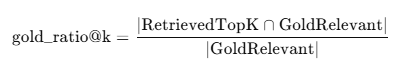

In [21]:
# 8.3 Evaluation metrics
def recall_at_k(retrieved_ids, relevant_ids):
    if not relevant_ids:
        return 0.0
    hits = len(set(retrieved_ids) & set(relevant_ids))
    return hits / len(relevant_ids)

def mrr(retrieved_ids, relevant_ids):
    for rank, cid in enumerate(retrieved_ids, start=1):
        if cid in relevant_ids:
            return 1.0 / rank
    return 0.0
def hit_at_k(retrieved_ids, relevant_ids, k):
    """how many relevant_ids are present in the top-k retrieved_ids?"""
    rel_set = set(relevant_ids)
    for cid in retrieved_ids[:k]:
        if cid in rel_set:
            return 1.0
    return 0.0

def gold_ratio_at_k(retrieved_ids, relevant_ids, k=None):
    """
    Ratio of gold items retrieved.
    Equivalent to (# overlapping) / (# gold items).

    - retrieved_ids: list of chunk_ids OR page numbers.
    - relevant_ids: list of gold chunk_ids OR gold page numbers.
    """
    if not relevant_ids:
        return 0.0

    if k is not None:
        retrieved_ids = retrieved_ids[:k]

    overlap = len(set(retrieved_ids) & set(relevant_ids))
    return overlap / len(relevant_ids)





In [22]:
# 8.4 Helper to map Document -> chunk_id quickly
content_to_id = {
    all_splits[i].page_content.strip(): f"chunk_{i}"
    for i in range(len(all_splits))
}

def docs_to_chunk_ids(docs, prefix_len=200):
    ids = []
    for doc in docs:
        page = doc.metadata.get("page")
        candidates = page_to_chunks.get(page, [])
        head = doc.page_content.strip()[:prefix_len]
        for cid in candidates:
            idx = int(cid.split("_")[1])
            if all_splits[idx].page_content.strip().startswith(head):
                ids.append(cid)
                break
    return ids

In [23]:
# 8.5 Evaluation loop
def eval_retriever_qa(retriever_fn, k=5):
    recalls, mrrs, hit_rates, precisions, gold_ratios = [], [], [], [], []

    for item in eval_questions:
        rel_ids = pages_to_chunk_ids(item["relevant_pages"])

        docs = retriever_fn(item["question"], k=k)
        retrieved_ids = docs_to_chunk_ids(docs)

        recalls.append(recall_at_k(retrieved_ids, rel_ids))
        mrrs.append(mrr(retrieved_ids, rel_ids))
        hit_rates.append(hit_at_k(retrieved_ids, rel_ids, k))        # 0/1
        gold_ratios.append(gold_ratio_at_k(retrieved_ids, rel_ids, k))

    return {
        "recall":      sum(recalls)/len(recalls),
        "mrr":         sum(mrrs)/len(mrrs),
        "hit_rate":    sum(hit_rates)/len(hit_rates),
        "gold_ratio":  sum(gold_ratios)/len(gold_ratios),
    }



In [24]:
def eval_retriever_summary(retriever_fn, k=5):
    recalls, mrrs, hit_rates, precisions, gold_ratios = [], [], [], [], []

    for item in eval_summaries:
        gold_physical = [p + PAGE_OFFSET for p in item["relevant_pages"]]

        docs = retriever_fn(item["question"], k=k)
        retrieved_pages = [
            int(d.metadata["page"])
            for d in docs
            if d.metadata.get("page") is not None
        ]

        recalls.append(recall_at_k(retrieved_pages, gold_physical))
        mrrs.append(mrr(retrieved_pages, gold_physical))
        hit_rates.append(hit_at_k(retrieved_pages, gold_physical, k))
        gold_ratios.append(gold_ratio_at_k(retrieved_pages, gold_physical, k))

    return {
        "recall":      sum(recalls)/len(recalls),
        "mrr":         sum(mrrs)/len(mrrs),
        "hit_rate":    sum(hit_rates)/len(hit_rates),
        "gold_ratio":  sum(gold_ratios)/len(gold_ratios),
    }


In [25]:
# 8.6 Run baseline vs graph
#take 10 eval questions only for quick test
# eval_questions = eval_questions[:10]
baseline_stats = eval_retriever_qa(lambda q, k: retrieve_baseline(q, k=k), k=5)
graph_stats    = eval_retriever_qa(lambda q, k: graph_retriever(q, k=k, expand_depth=2, task="fine_qa"), k=5)

print(baseline_stats)
print(graph_stats)



{'recall': 0.13550347222222223, 'mrr': 0.53125, 'hit_rate': 0.53125, 'gold_ratio': 0.13550347222222223}
{'recall': 0.3423735119047619, 'mrr': 0.5671875, 'hit_rate': 0.65625, 'gold_ratio': 0.3423735119047619}


In [26]:
summary_baseline_stats = eval_retriever_summary(
    retriever_fn=lambda q, k: retrieve_baseline(q, k=k),
    k=20,
)

summary_graph_stats = eval_retriever_summary(
    retriever_fn=lambda q, k: graph_retriever(q, k=k, expand_depth=3, task="summary"),
    k=20,
)

print("Baseline (summary):", summary_baseline_stats)
print("Graph (summary):   ", summary_graph_stats)


Baseline (summary): {'recall': 0.14444444444444443, 'mrr': 0.22222222222222224, 'hit_rate': 0.4, 'gold_ratio': 0.14444444444444443}
Graph (summary):    {'recall': 0.538888888888889, 'mrr': 0.395, 'hit_rate': 0.8, 'gold_ratio': 0.538888888888889}


In [27]:
import time

q = "Who is seen as the father of behaviorism within psychology?"

t0 = time.time()
docs_b = retrieve_baseline(q, k=5)
t1 = time.time()
print("Baseline retrieval time:", t1 - t0, "seconds")


Baseline retrieval time: 0.005980253219604492 seconds


In [28]:
t0 = time.time()
docs_g = graph_retriever(q, k=5, expand_depth=1, task="fine_qa")
t1 = time.time()
print("Graph retrieval time:", t1 - t0, "seconds")


Graph retrieval time: 0.0069768428802490234 seconds


In [30]:
def eval_depth_ablation(depth_list=[0,1,2,3], k=5):
    results = []
    for d in depth_list:
        stats = eval_retriever_qa(
            retriever_fn=lambda q, k=k: graph_retriever(
                q,
                k=k,
                expand_depth=d,
                task="fine_qa"
            ),
            k=k
        )
        results.append((d, stats))
    return results
ablation_results = eval_depth_ablation()
for d, stats in ablation_results:
    print("Depth =", d, "->", stats)


Depth = 0 -> {'recall': 0.13550347222222223, 'mrr': 0.53125, 'hit_rate': 0.53125, 'gold_ratio': 0.13550347222222223}
Depth = 1 -> {'recall': 0.47361111111111115, 'mrr': 0.5416666666666666, 'hit_rate': 0.5625, 'gold_ratio': 0.47361111111111115}
Depth = 2 -> {'recall': 0.3423735119047619, 'mrr': 0.5671875, 'hit_rate': 0.65625, 'gold_ratio': 0.3423735119047619}
Depth = 3 -> {'recall': 0.21276041666666665, 'mrr': 0.5416666666666666, 'hit_rate': 0.5625, 'gold_ratio': 0.21276041666666665}


In [31]:
def measure_latency(retriever_fn, queries, k=5):
    times = []
    for item in queries:
        q = item["question"]
        t0 = time.time()
        retriever_fn(q, k=k)
        t1 = time.time()
        times.append(t1 - t0)
    return sum(times) / len(times)

baseline_latency = measure_latency(
    lambda q, k: retrieve_baseline(q, k=k),
    eval_questions,
    k=5
)

print("Baseline latency (avg):", baseline_latency)
graph_latency = measure_latency(
    lambda q, k: graph_retriever(q, k=k, expand_depth=2, task="fine_qa"),
    eval_questions,
    k=5
)

print("Graph latency (avg):", graph_latency)


Baseline latency (avg): 0.009448520839214325
Graph latency (avg): 0.010449200868606567
